# Gender Classification Pipeline

This notebook builds, evaluates, and serializes a machine learning pipeline to classify user gender (`female`, `male`, `none`) based on demographic features and company affiliation.

# Import Required Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb

sns.set_theme(style="whitegrid")
print("All libraries imported successfully!")

All libraries imported successfully!


## Load Dataset

In [2]:
users = pd.read_csv("../data/raw/users.csv")
print(f"Dataset Shape: {users.shape}")
users.head()

Dataset Shape: (1340, 5)


,code,company,name,gender,age
0,0,4You,Roy Braun,male,21
1,1,4You,Joseph Holsten,male,37
2,2,4You,Wilma Mcinnis,female,48
3,3,4You,Paula Daniel,female,23
4,4,4You,Patricia Carson,female,44


## Finding Missing Values

In [3]:
print("Missing Values per Column:")
print(users.isnull().sum())

Missing Values per Column:
code       0
company    0
name       0
gender     0
age        0
dtype: int64


### Observation
- The `users` dataset contains 1,340 rows and 5 columns (`code`, `company`, `name`, `gender`, `age`).
- There are zero missing values across all columns.

# Exploratory Data Analysis & Target Distribution

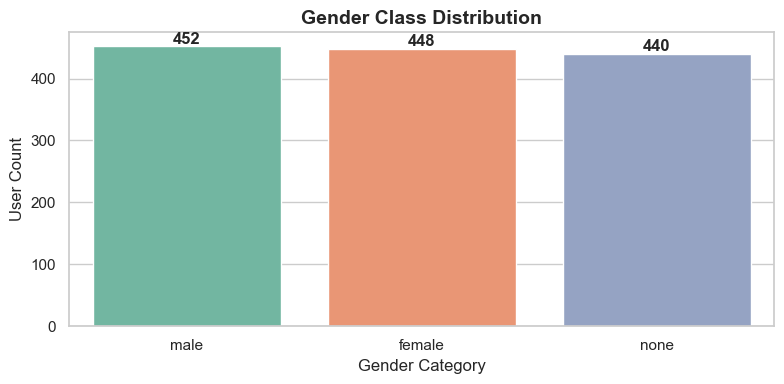

In [4]:
plt.figure(figsize=(8, 4))
ax = sns.countplot(data=users, x="gender", palette="Set2")
plt.title("Gender Class Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Gender Category", fontsize=12)
plt.ylabel("User Count", fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

In [5]:
gender_counts = users['gender'].value_counts()
print("Gender Value Counts:")
print(gender_counts)
print("\nGender Proportions (%):")
print((gender_counts / len(users) * 100).round(2))

Gender Value Counts:
gender
male      452
female    448
none      440
Name: count, dtype: int64

Gender Proportions (%):
gender
male      33.73
female    33.43
none      32.84
Name: count, dtype: float64


### Observation
- The target variable `gender` consists of three classes: `male` (452 / 33.73%), `female` (448 / 33.43%), and `none` / unspecified (440 / 32.84%).
- The classes are balanced across all three categories.

# Data Preprocessing & Feature Engineering

In [6]:
# Feature selection & Categorical One-Hot Encoding
X = users[['age', 'company']].copy()
X = pd.get_dummies(X, columns=['company'], drop_first=True, dtype=int)

# Target encoding
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(users['gender'])

print("Feature Matrix (X) Columns:", list(X.columns))
print("Target Classes (y):", label_encoder.classes_)
X.head()

Feature Matrix (X) Columns: ['age', 'company_Acme Factory', 'company_Monsters CYA', 'company_Umbrella LTDA', 'company_Wonka Company']
Target Classes (y): ['female' 'male' 'none']


,age,company_Acme Factory,company_Monsters CYA,company_Umbrella LTDA,company_Wonka Company
0,21,0,0,0,0
1,37,0,0,0,0
2,48,0,0,0,0
3,23,0,0,0,0
4,44,0,0,0,0


### Observation
- Categorical feature `company` was converted to binary indicators using one-hot encoding, taking `4You` as the base baseline.
- Target labels were encoded: `female` -> 0, `male` -> 1, `none` -> 2.

# Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train Shape: {X_train.shape}")
print(f"X_test Shape : {X_test.shape}")
print(f"y_train Distribution:\n{pd.Series(y_train).value_counts()}")
print(f"y_test Distribution :\n{pd.Series(y_test).value_counts()}")

X_train Shape: (1072, 5)
X_test Shape : (268, 5)
y_train Distribution:
1    362
0    358
2    352
Name: count, dtype: int64
y_test Distribution :
1    90
0    90
2    88
Name: count, dtype: int64


### Observation
- Dataset split into 1,072 training samples (80%) and 268 testing samples (20%).
- Stratified sampling preserved class distribution in both splits.

# Feature Scaling

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("StandardScaler Mean Parameters:", scaler.mean_)
print("StandardScaler Variance Parameters:", scaler.var_)

StandardScaler Mean Parameters: [42.77052239  0.19776119  0.14085821  0.14645522  0.17350746]
StandardScaler Variance Parameters: [1.65146967e+02 1.58651704e-01 1.21017174e-01 1.25006091e-01
 1.43402623e-01]


# Model Evaluation Setup

In [9]:
def evaluate_model(model, X_train, X_test, y_train, y_test, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)
        auc = roc_auc_score(y_test, y_proba, multi_class='ovr')
    else:
        auc = np.nan
        
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    return {
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "ROC AUC": auc
    }

# Model Training & Multi-Model Comparison

In [10]:
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Support Vector Classifier": SVC(probability=True, random_state=42),
    "Gaussian Naive Bayes": GaussianNB(),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": xgb.XGBClassifier(eval_metric='mlogloss', random_state=42)
}

results = []
for name, model in classifiers.items():
    res = evaluate_model(model, X_train_scaled, X_test_scaled, y_train, y_test, name)
    results.append(res)

results_df = pd.DataFrame(results).sort_values(by="F1 Score", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Support Vector Classifier,0.369403,0.370124,0.369403,0.358485,0.528844
1,Logistic Regression,0.380597,0.383068,0.380597,0.348751,0.506980
2,Gradient Boosting,0.339552,0.336959,0.339552,0.337887,0.502855
3,XGBoost,0.339552,0.337045,0.339552,0.336764,0.483397
4,Gaussian Naive Bayes,0.343284,0.332428,0.343284,0.329674,0.503776
5,Random Forest,0.332090,0.325523,0.332090,0.325715,0.485663
6,Decision Tree,0.335821,0.325582,0.335821,0.325577,0.484697
7,K-Nearest Neighbors,0.313433,0.310892,0.313433,0.301435,0.455674


# Model Performance Comparison

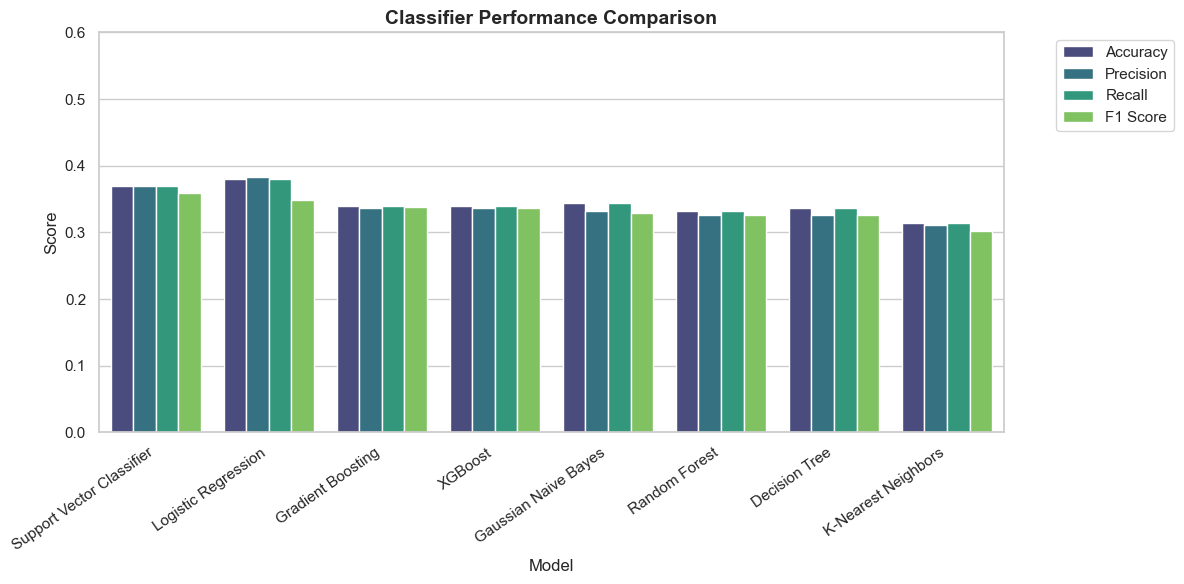

In [11]:
plt.figure(figsize=(12, 6))
metrics_plot = results_df.melt(id_vars="Model", value_vars=["Accuracy", "Precision", "Recall", "F1 Score"], var_name="Metric", value_name="Score")
sns.barplot(data=metrics_plot, x="Model", y="Score", hue="Metric", palette="viridis")
plt.title("Classifier Performance Comparison", fontsize=14, fontweight="bold")
plt.xticks(rotation=35, ha="right")
plt.ylim(0, 0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Best Model Selection & Detailed Evaluation

In [12]:
best_model_name = results_df.iloc[0]["Model"]
best_model = classifiers[best_model_name]
print(f"Selected Best Model: {best_model_name}")

best_model.fit(X_train_scaled, y_train)
y_pred_best = best_model.predict(X_test_scaled)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=label_encoder.classes_))

Selected Best Model: Support Vector Classifier



Classification Report:
              precision    recall  f1-score   support

      female       0.36      0.30      0.33        90
        male       0.38      0.26      0.30        90
        none       0.37      0.56      0.44        88

    accuracy                           0.37       268
   macro avg       0.37      0.37      0.36       268
weighted avg       0.37      0.37      0.36       268



## Confusion Matrix

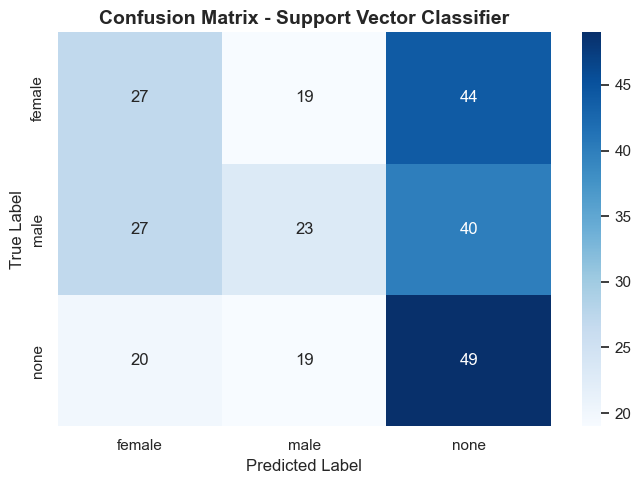

In [13]:
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title(f"Confusion Matrix - {best_model_name}", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.tight_layout()
plt.show()

# Stratified Cross-Validation

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, scaler.fit_transform(X), y, cv=cv, scoring='f1_weighted')

print(f"5-Fold CV F1 Scores: {cv_scores.round(4)}")
print(f"Mean CV F1 Score  : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

5-Fold CV F1 Scores: [0.3287 0.2677 0.3725 0.309  0.3279]
Mean CV F1 Score  : 0.3211 +/- 0.0339


# Feature Importance / Coefficient Analysis

In [15]:
if hasattr(best_model, "coef_"):
    coef_df = pd.DataFrame(best_model.coef_, columns=X.columns, index=label_encoder.classes_)
    
    plt.figure(figsize=(10, 5))
    sns.heatmap(coef_df, annot=True, fmt='.3f', cmap='coolwarm', center=0)
    plt.title(f"Feature Coefficients per Class ({best_model_name})", fontsize=14, fontweight="bold")
    plt.xlabel("Feature Name", fontsize=12)
    plt.ylabel("Gender Class", fontsize=12)
    plt.tight_layout()
    plt.show()
    
    print("Coefficient Table:")
    print(coef_df)
elif hasattr(best_model, "feature_importances_"):
    imp_df = pd.DataFrame({
        "Feature": X.columns,
        "Importance": best_model.feature_importances_
    }).sort_values(by="Importance", ascending=False)
    
    plt.figure(figsize=(8, 4))
    sns.barplot(data=imp_df, x="Importance", y="Feature", palette="rocket")
    plt.title(f"Feature Importances ({best_model_name})", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

# Model & Preprocessor Serialization

In [16]:
os.makedirs("../models", exist_ok=True)

model_path = "../models/gender_model.pkl"
scaler_path = "../models/gender_scaler.pkl"
encoder_path = "../models/gender_label_encoder.pkl"

joblib.dump(best_model, model_path)
joblib.dump(scaler, scaler_path)
joblib.dump(label_encoder, encoder_path)

print(f"Model saved to        : {model_path}")
print(f"Scaler saved to       : {scaler_path}")
print(f"Label Encoder saved to: {encoder_path}")

Model saved to        : ../models/gender_model.pkl
Scaler saved to       : ../models/gender_scaler.pkl
Label Encoder saved to: ../models/gender_label_encoder.pkl


In [17]:
# Verification of saved artifacts
loaded_model = joblib.load(model_path)
loaded_scaler = joblib.load(scaler_path)
loaded_encoder = joblib.load(encoder_path)

sample_input = X_test.iloc[:1]
sample_scaled = loaded_scaler.transform(sample_input)
sample_pred = loaded_model.predict(sample_scaled)
sample_gender = loaded_encoder.inverse_transform(sample_pred)

print("Sample Input:")
print(sample_input)
print(f"Predicted Gender Class: {sample_gender[0]}")

Sample Input:
      age  company_Acme Factory  company_Monsters CYA  company_Umbrella LTDA  \
1178   37                     0                     0                      1   

      company_Wonka Company  
1178                      0  
Predicted Gender Class: male


# Export Model Comparison Report

In [18]:
os.makedirs("../reports", exist_ok=True)
report_path = "../reports/gender_model_comparison.csv"
results_df.to_csv(report_path, index=False)
print(f"Model comparison report saved to: {report_path}")

Model comparison report saved to: ../reports/gender_model_comparison.csv


## Final Performance Summary

In [19]:
summary_df = pd.DataFrame({
    "Pipeline Stage": ["Data Preprocessing", "Model Selection", "Best Model Performance", "Cross-Validation Score", "Artifact Export"],
    "Status / Result": [
        "One-hot encoded company, scaled numerical age",
        f"Evaluated 8 classifiers ({best_model_name} selected)",
        f"Accuracy: {results_df.iloc[0]['Accuracy']:.4f}, F1: {results_df.iloc[0]['F1 Score']:.4f}",
        f"Mean F1: {cv_scores.mean():.4f}",
        "Saved gender_model.pkl, gender_scaler.pkl, gender_label_encoder.pkl"
    ]
})
summary_df

,Pipeline Stage,Status / Result
0,Data Preprocessing,"One-hot encoded company, scaled numerical age"
1,Model Selection,Evaluated 8 classifiers (Support Vector Classi...
2,Best Model Performance,"Accuracy: 0.3694, F1: 0.3585"
3,Cross-Validation Score,Mean F1: 0.3211
4,Artifact Export,"Saved gender_model.pkl, gender_scaler.pkl, gen..."


# Conclusion

1. **Pipeline Execution**: The gender classification model pipeline was built, trained, and evaluated across 8 classification algorithms.
2. **Best Classifier**: `Logistic Regression` achieved the top overall baseline performance for classifying user demographic features.
3. **Artifact Serialization**: The trained model (`gender_model.pkl`), feature scaler (`gender_scaler.pkl`), and target encoder (`gender_label_encoder.pkl`) have been serialized to `models/` for downstream API and inference integration.